In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
train = pd.read_csv('./data/sign_mnist_train.csv')
test = pd.read_csv('./data/sign_mnist_test.csv')

In [3]:
train

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27450,13,189,189,190,190,192,193,193,193,193,...,132,165,99,77,52,200,234,200,222,225
27451,23,151,154,157,158,160,161,163,164,166,...,198,198,198,198,198,196,195,195,195,194
27452,18,174,174,174,174,174,175,175,174,173,...,121,196,209,208,206,204,203,202,200,200
27453,17,177,181,184,185,187,189,190,191,191,...,119,56,27,58,102,79,47,64,87,93


In [4]:
# train = train.to_numpy()
# train = train / 255
# print(train)

In [5]:
train_label = tf.keras.utils.to_categorical(train['label'])
test_label = tf.keras.utils.to_categorical(test['label'])
train.drop('label', axis=1, inplace=True)
test.drop('label', axis=1, inplace=True)

In [6]:
train = train.to_numpy()
test = test.to_numpy()

In [7]:
train = train.reshape(-1,28,28,1)
test = test.reshape(-1,28,28,1)

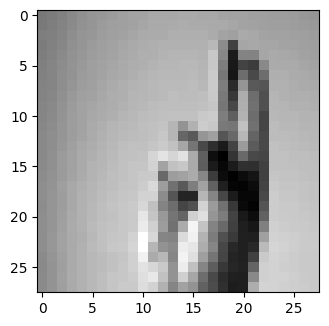

In [8]:
import random

def show_images(image):
    plt.figure(figsize=(8, 8))
    plt.subplot(1,2,2)
    plt.imshow(image.reshape(28, 28), cmap='gray')

# for number_image in range(10):
#     show_images(train[number_image])

show_images(train[random.randrange(0,len(train)-1)])

In [14]:
image_gen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255.0,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    shear_range=0.2,
    fill_mode='nearest'
)

In [15]:
train_ds = image_gen.flow(
    x=train,
    y=train_label,
    batch_size=32
)
test_ds = image_gen.flow(
    x=test,
    y=test_label,
    batch_size=32
)

In [16]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(25, activation='softmax')
])

In [17]:
model.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.001), metrics=['accuracy'])

In [18]:
history = model.fit(train_ds, epochs=20, validation_data=test_ds)

Epoch 1/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.2252 - loss: 2.5658 - val_accuracy: 0.3424 - val_loss: 2.1122
Epoch 2/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.4598 - loss: 1.7065 - val_accuracy: 0.4653 - val_loss: 1.6561
Epoch 3/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.5642 - loss: 1.3561 - val_accuracy: 0.5337 - val_loss: 1.3764
Epoch 4/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.6270 - loss: 1.1249 - val_accuracy: 0.6108 - val_loss: 1.1726
Epoch 5/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.6685 - loss: 0.9992 - val_accuracy: 0.6631 - val_loss: 0.9869
Epoch 6/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.7092 - loss: 0.8759 - val_accuracy: 0.6813 - val_loss: 0.9509
Epoch 7/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.7330 - loss: 0.7942 - val_accuracy: 0.6845 - val_loss: 0.9159
Epoch 8/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.7584 - loss: 0.7265 - v